In [78]:
import pandas as pd
import matplotlib.pyplot as plt


In [79]:
import pandas as pd

# 1️⃣ Mappa mese → file CSV
month_files = {
    3: 'marzo_daily_avg_per_zone.csv',
    5: 'maggio_daily_avg_per_zone.csv',
    8: 'agosto_daily_avg_per_zone.csv',
    9: 'settembre_daily_avg_per_zone.csv'
}

# 2️⃣ Lista per contenere DataFrame dei singoli mesi
dfs = []

for month, file in month_files.items():
    # Leggi CSV (modifica sep se necessario)
    df = pd.read_csv(file, sep=',')  # oppure sep='\t' se tab-separated

    # Normalizza nomi colonne
    df.columns = df.columns.str.strip()

    # Crea colonna 'data' a partire da 'Numero_Giorno' e mese corrente
    df['data'] = pd.to_datetime(f'2025-{month:02d}-01') + pd.to_timedelta(df['Numero_Giorno'] - 1, unit='d')

    dfs.append(df)

# 3️⃣ Unisci tutti i DataFrame
df_all = pd.concat(dfs, ignore_index=True)

# 4️⃣ Trasforma in wide format (data, aeroporto, fiera)
df_wide = df_all.pivot(index='data', columns='Zona', values='P').reset_index()
df_wide.columns.name = None
df_wide = df_wide.rename(columns={'Aeroporto':'aeroporto', 'Fiera':'fiera'})

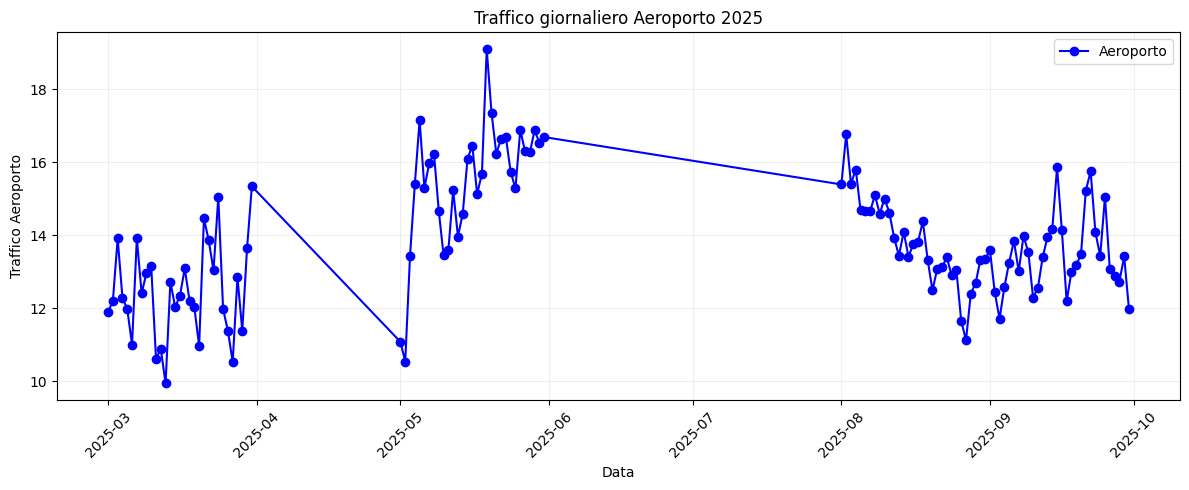

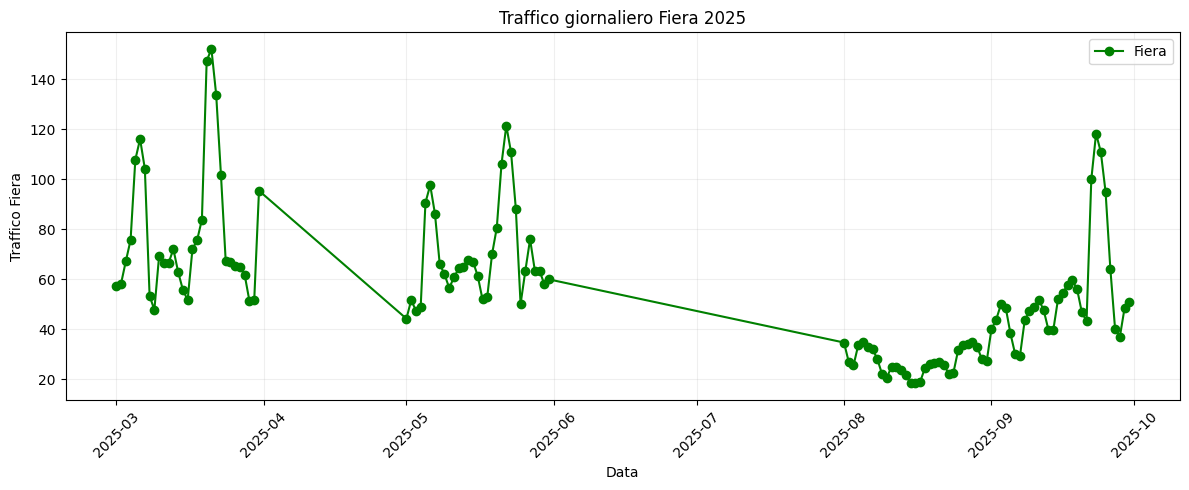

In [80]:

# ------------------------------
# Grafico 1: Aeroporto
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_wide['data'], df_wide['aeroporto'], label='Aeroporto', marker='o', color='blue')
plt.xlabel('Data')
plt.ylabel('Traffico Aeroporto')
plt.title('Traffico giornaliero Aeroporto 2025')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# Grafico 2: Fiera
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_wide['data'], df_wide['fiera'], label='Fiera', marker='o', color='green')
plt.xlabel('Data')
plt.ylabel('Traffico Fiera')
plt.title('Traffico giornaliero Fiera 2025')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [81]:
import pandas as pd
import numpy as np

# Assicura datetime
df_wide["data"] = pd.to_datetime(df_wide["data"])

# Giorno della settimana: lun=0 ... dom=6
df_wide["dow"] = df_wide["data"].dt.weekday

# Settimana ISO
df_wide["year"] = df_wide["data"].dt.isocalendar().year
df_wide["week"] = df_wide["data"].dt.isocalendar().week

# ===============================
# 1️⃣ Somma fiera lun–ven per settimana
# ===============================
weekly_fiera = (
    df_wide[df_wide["dow"] <= 4]       # lun–ven
    .groupby(["year", "week"])["fiera"]
    .sum()
    .rename("fiera_lun_ven")
    .reset_index()
)

# ===============================
# 2️⃣ Merge sul dataframe originale
# ===============================
df_wide = df_wide.merge(
    weekly_fiera,
    on=["year", "week"],
    how="left"
)

# ===============================
# 3️⃣ Nuova feature
# ===============================
df_wide["fiera_weekend_lunven"] = np.where(
    df_wide["dow"] >= 5,         # sabato o domenica
    df_wide["fiera_lun_ven"],    # somma lun–ven
    0
)

# Pulizia (opzionale)
df_wide["fiera_weekend_lunven"] = df_wide["fiera_weekend_lunven"].fillna(0)
df_wide


,data,aeroporto,fiera,dow,year,week,fiera_lun_ven,fiera_weekend_lunven
0,2025-03-01,11.898493,57.314352,5,2025,9,NaN,0.000000
1,2025-03-02,12.190898,58.357870,6,2025,9,NaN,0.000000
2,2025-03-03,13.906398,67.268056,0,2025,10,471.278530,0.000000
3,2025-03-04,12.280733,75.725810,1,2025,10,471.278530,0.000000
4,2025-03-05,11.969858,107.874595,2,2025,10,471.278530,0.000000
...,...,...,...,...,...,...,...,...
118,2025-09-26,13.070700,64.362269,4,2025,39,488.628877,0.000000
119,2025-09-27,12.884752,40.171181,5,2025,39,488.628877,488.628877
120,2025-09-28,12.722961,37.002315,6,2025,39,488.628877,488.628877
121,2025-09-29,13.415189,48.592477,0,2025,40,99.672564,0.000000


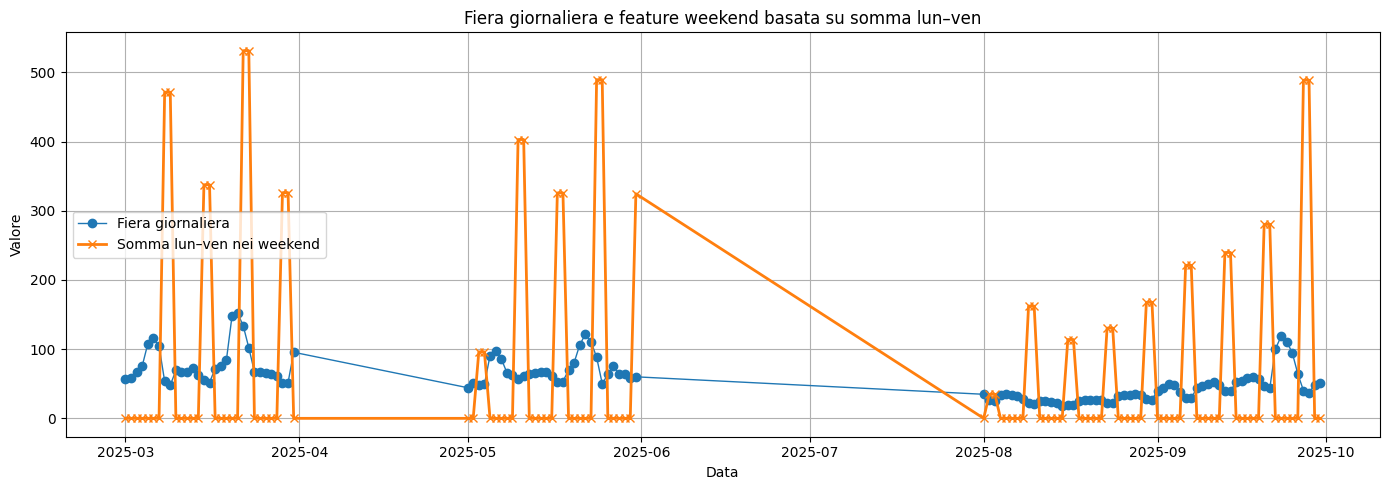

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Linea fiera giornaliera
plt.plot(df_wide["data"], df_wide["fiera"], label="Fiera giornaliera", marker="o", linewidth=1)

# Linea nuova feature
plt.plot(df_wide["data"], df_wide["fiera_weekend_lunven"], label="Somma lun–ven nei weekend", marker="x", linewidth=2)

plt.xlabel("Data")
plt.ylabel("Valore")
plt.title("Fiera giornaliera e feature weekend basata su somma lun–ven")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


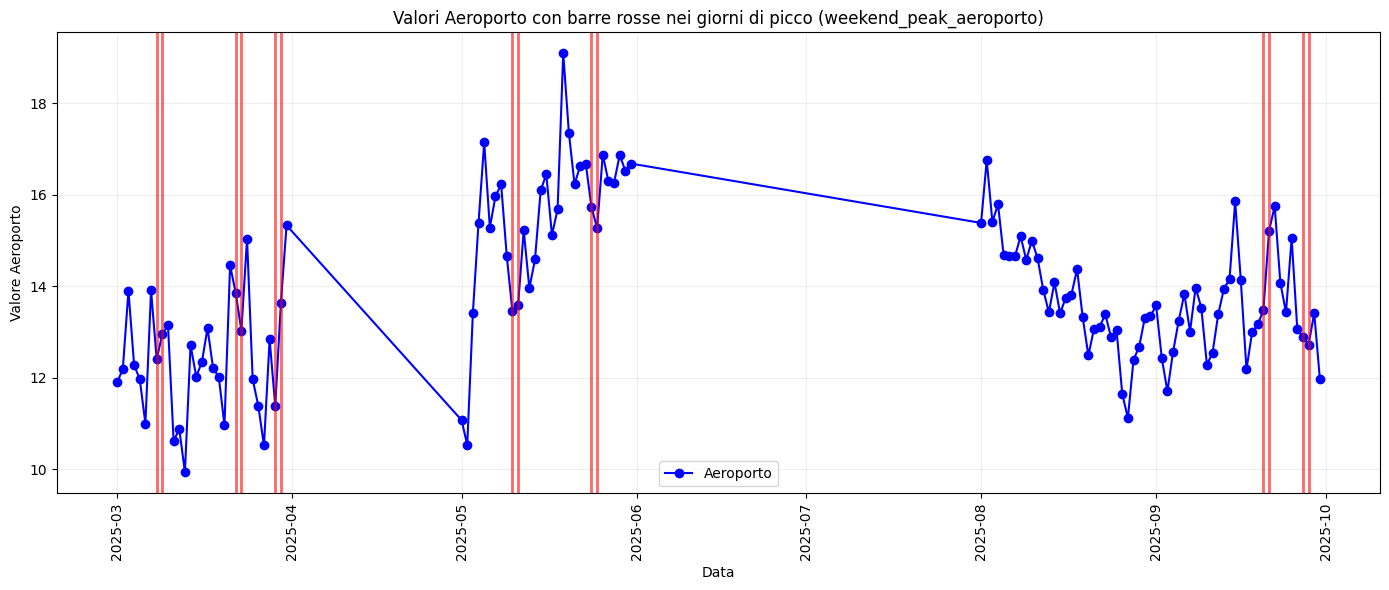

In [83]:
from scipy.signal import find_peaks

# Trova i picchi verso il basso (minimi locali)
peaks_airport_down, _ = find_peaks(df_wide["aeroporto"], prominence=2)
df_peaks_airport_down = df_wide.iloc[peaks_airport_down].copy()

# Aggiungi info settimana e anno
df_peaks_airport_down["year_week"] = df_peaks_airport_down["data"].dt.isocalendar().week
df_peaks_airport_down["year"] = df_peaks_airport_down["data"].dt.isocalendar().year

peak_weeks_airport_down = set(zip(df_peaks_airport_down["year"], df_peaks_airport_down["year_week"]))

# Crea colonna weekend_peak verso il basso
df_wide["evento_aeroporto"] = 0

for idx, row in df_wide.iterrows():
    year = row["data"].isocalendar().year
    week = row["data"].isocalendar().week
    weekday = row["data"].weekday()  # 0=lunedì, 5=sabato, 6=domenica
    if (year, week) in peak_weeks_airport_down and weekday >= 5:
        df_wide.at[idx, "evento_aeroporto"] = 1


plt.figure(figsize=(14,6))

# Linea principale
plt.plot(df_wide["data"], df_wide["aeroporto"], label="Aeroporto", marker='o', color='blue')

# Barre rosse verticali per giorni peak
for d in df_wide[df_wide["evento_aeroporto"] == 1]["data"]:
    plt.axvline(x=d, color='red', alpha=0.6, linewidth=2)

# Formattazione
plt.xlabel("Data")
plt.ylabel("Valore Aeroporto")
plt.title("Valori Aeroporto con barre rosse nei giorni di picco (weekend_peak_aeroporto)")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
df_wide = df_wide.drop(columns=["fiera_lun_ven"])
df_wide

,data,aeroporto,fiera,dow,year,week,fiera_weekend_lunven,evento_aeroporto
0,2025-03-01,11.898493,57.314352,5,2025,9,0.000000,0
1,2025-03-02,12.190898,58.357870,6,2025,9,0.000000,0
2,2025-03-03,13.906398,67.268056,0,2025,10,0.000000,0
3,2025-03-04,12.280733,75.725810,1,2025,10,0.000000,0
4,2025-03-05,11.969858,107.874595,2,2025,10,0.000000,0
...,...,...,...,...,...,...,...,...
118,2025-09-26,13.070700,64.362269,4,2025,39,0.000000,0
119,2025-09-27,12.884752,40.171181,5,2025,39,488.628877,1
120,2025-09-28,12.722961,37.002315,6,2025,39,488.628877,1
121,2025-09-29,13.415189,48.592477,0,2025,40,0.000000,0


In [85]:
# Salva in CSV
df_wide.to_csv('eventi_aeroporto_fiera.csv', index=False)
